# Gamma Correcion

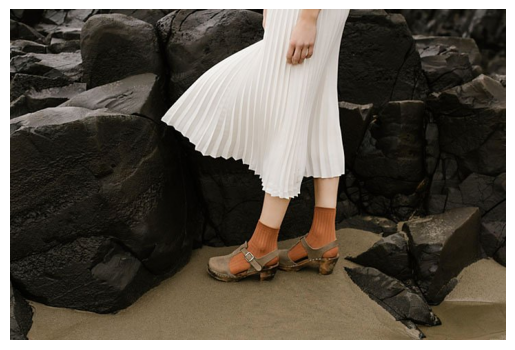

In [ ]:
# import required libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('gamma.jpg')

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


plt.imshow(image_rgb)
plt.axis('off')
plt.show()

Convert to L*a*b color space

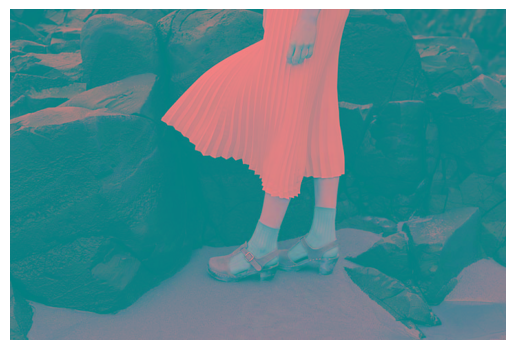

In [3]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

plt.imshow(image_lab)
plt.axis('off')
plt.show()

(a)Gamma correction

In [4]:
# Select the L channel
L_channel = image_lab[:, :, 0]

# Normalize the L channel to the range [0, 1]
L_normal = L_channel / 255.0

# Apply gamma correction with gamma = 0.5 

'''
When you map intensity values from one range to another, you can optionally perform a nonlinear mapping using gamma correction. The gamma correction factor can be any value between 0 and infinity.

When gamma is less than 1, the mapping is weighted toward higher (brighter) output values.

When gamma is greater than 1, the mapping is weighted toward lower (darker) output values.

When gamma is exactly 1, the mapping is linear.
'''
gamma = 0.5

# Apply gamma correction
L_gamma = np.power(L_normal, gamma)

# Scale back to [0,255]
L_corrected = np.uint8(L_gamma * 255)

# Merge the corrected L channel back with the original a and b channels
lab_corrected = image_lab.copy()
lab_corrected[:, :, 0] = L_corrected




Convert into RGB space 

In [5]:
# Conver to rgb color space
rgb_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

Plot Original and Gamma Corrected Images

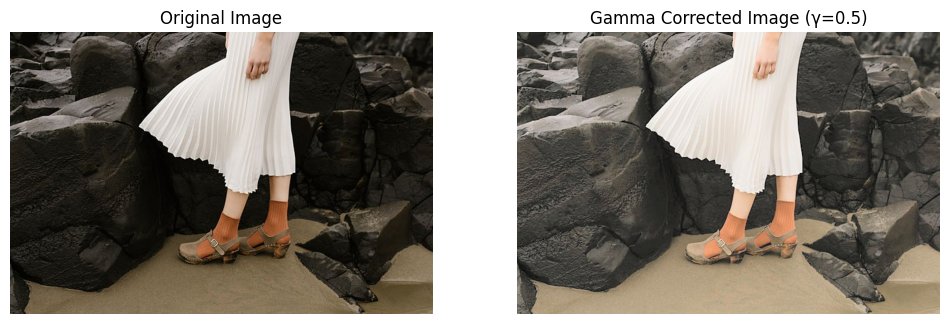

In [6]:
# Plot images
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_corrected)
plt.title(f'Gamma Corrected Image (γ={gamma})')
plt.axis('off')
plt.show()


(b) Hisograms of original and corrected images

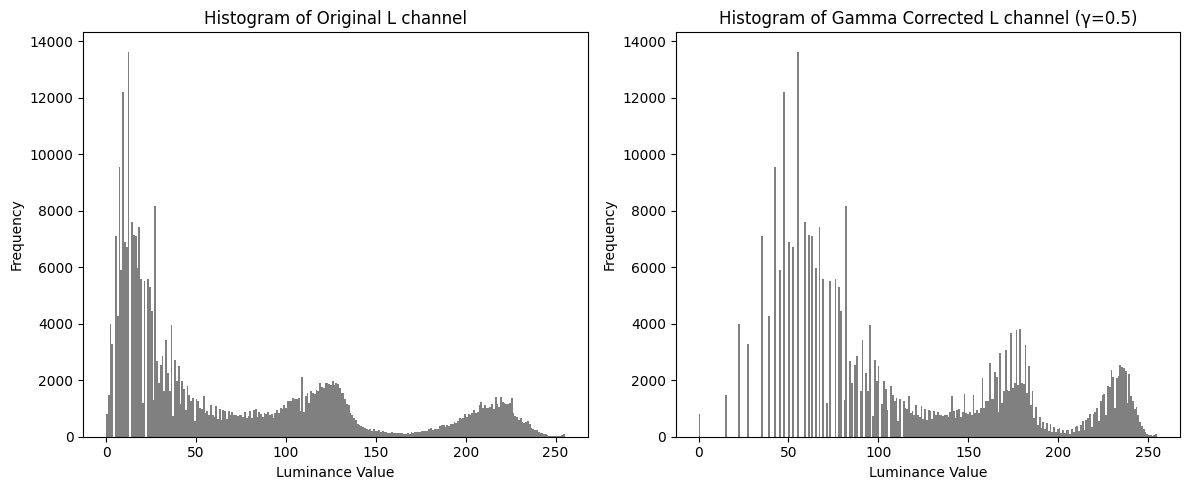

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(L_channel.flatten(), bins=256, range=(0, 255), color='gray')
plt.title('Histogram of Original L channel')
plt.xlabel('Luminance Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(L_corrected.flatten(), bins=256, range=(0, 255), color='gray')
plt.title(f'Histogram of Gamma Corrected L channel (γ={gamma})')
plt.xlabel('Luminance Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()